# Timbre Feature Extraction

Extract per-frame timbre features (and optionally pitch-aligned F0) from every
audio file in a directory.  Concatenate all frames into a single feature matrix
and save it for downstream use (e.g. as a reference distribution for evaluation).

**Configure the cells below, then Run All.**

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation.timbre_metrics import TimbreMetrics
from evaluation.pitch_metrics import PitchMetrics
from utils import load_audio

print(f"Project root: {PROJECT_ROOT}")

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /m/home/home3/37/thieun1/unix/Project/final_project


## Configuration

Edit **only this cell** to point at a different audio folder, change the
output name, select feature types, or toggle F0 extraction.

In [3]:
# ── Audio source ──────────────────────────────────────────────────────
AUDIO_DIR = PROJECT_ROOT / "data" / "processed" / "voice" / "Full_sms_baseline"
AUDIO_EXTENSIONS = {".wav", ".mp3", ".opus", ".flac", ".ogg"}

# ── Optional metadata CSV ─────────────────────────────────────────────
# Set to None if there is no metadata file.
# If provided, must have a column whose values match the audio filenames.
METADATA_CSV = None
METADATA_KEY = None         # column in CSV that matches audio filenames
METADATA_COLS = None  # columns to keep

# ── Output ─────────────────────────────────────────────────────────────
OUT_DIR  = PROJECT_ROOT / "data" / "processed"
OUT_NAME = "sms_features"   # .parquet and .npz will be appended

# ── Feature extraction parameters ────────────────────────────────────
SR            = 16_000
FRAME_WIDTH   = 0.25        # seconds per analysis frame
OVERLAP       = 0.0         # fraction overlap between frames
FEATURE_TYPES = ["spectral"]   # any of: "spectral", "level", "harmonic"
METRICS       = [
        "spectral_centroid",
        "spectral_crest",
        "spectral_decrease",
        "spectral_flatness",
        "spectral_roll_off",
        "spectral_skewness",
        "spectral_spread",
        ]        # None = all metrics for selected types;
                            # or a list like ["spectral_centroid", "spectral_spread"]

# ── Silence trimming ─────────────────────────────────────────────────
TRIM_SILENCE      = False    # trim leading/trailing silence before extraction
TRIM_TOP_DB       = 30      # threshold in dB below peak to consider as silence
TRIM_FRAME_LENGTH = 2048    # FFT size for silence detection
TRIM_HOP_LENGTH   = 512     # hop size for silence detection

# ── Pitch (F0) extraction ─────────────────────────────────────────────
EXTRACT_F0            = True
F0_CONFIDENCE_THRESH  = 0.00   # mask frames below this confidence

# ── Sanity-check ──────────────────────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Audio dir : {AUDIO_DIR}  (exists: {AUDIO_DIR.exists()})")
print(f"Metadata  : {METADATA_CSV}  (exists: {METADATA_CSV.exists() if METADATA_CSV else 'N/A'})")
print(f"Output dir: {OUT_DIR}")
print(f"Features  : {FEATURE_TYPES}  |  Metrics filter: {METRICS}")
print(f"Trim silence: {TRIM_SILENCE}  |  top_db: {TRIM_TOP_DB}")
print(f"Extract F0: {EXTRACT_F0}  |  Confidence threshold: {F0_CONFIDENCE_THRESH}")

Audio dir : /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/voice/Full_sms_baseline  (exists: True)
Metadata  : None  (exists: N/A)
Output dir: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed
Features  : ['spectral']  |  Metrics filter: ['spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_flatness', 'spectral_roll_off', 'spectral_skewness', 'spectral_spread']
Trim silence: False  |  top_db: 30
Extract F0: True  |  Confidence threshold: 0.0


## 1. Discover audio files and load metadata

In [4]:
audio_files = sorted(
    p for p in AUDIO_DIR.rglob("*")
    if p.suffix.lower() in AUDIO_EXTENSIONS
)
print(f"Found {len(audio_files)} audio files")

# Optional metadata
meta_lookup: dict = {}
if METADATA_CSV and Path(METADATA_CSV).exists():
    meta_df = pd.read_csv(METADATA_CSV)
    meta_lookup = meta_df.set_index(METADATA_KEY).to_dict(orient="index")
    print(f"Metadata rows: {len(meta_df)}  |  Columns kept: {METADATA_COLS}")
    display(meta_df.head())
else:
    print("No metadata CSV — only filename will be stored.")

Found 3095 audio files
No metadata CSV — only filename will be stored.


## 2. Extract per-frame features for every file

In [5]:
import librosa

tm = TimbreMetrics(sample_rate=SR, frame_width_sec=FRAME_WIDTH, overlap_pct=OVERLAP)

all_records: list[dict] = []
failed: list[str] = []

for path in tqdm(audio_files, desc="Extracting"):
    try:
        audio, _ = load_audio(path, sr=SR, mono=True)

        # Trim leading/trailing silence
        if TRIM_SILENCE:
            audio, _ = librosa.effects.trim(
                audio,
                top_db=TRIM_TOP_DB,
                frame_length=TRIM_FRAME_LENGTH,
                hop_length=TRIM_HOP_LENGTH,
            )

        # Spectral / level / harmonic features
        series = tm.extract_series_from_array(
            audio, metrics=METRICS, feature_types=FEATURE_TYPES,
        )
        if not series:
            raise ValueError("empty features")

        n_frames = len(next(iter(series.values())))

        # Pitch extraction (aligned to the same frame grid) via CREPE
        if EXTRACT_F0:
            f0, conf = PitchMetrics.extract_f0(
                audio,
                sample_rate=SR,
                frame_width_sec=FRAME_WIDTH,
                overlap_pct=OVERLAP,
            )
            n = min(n_frames, len(f0))
            series = {k: v[:n] for k, v in series.items()}
            f0 = f0[:n]
            conf = conf[:n]
            f0[conf < F0_CONFIDENCE_THRESH] = np.nan
            series["f0_hz"] = f0
            series["f0_confidence"] = conf
            n_frames = n

    except Exception as e:
        print(f"  SKIP {path.name}: {e}")
        failed.append(path.name)
        continue

    meta = meta_lookup.get(path.name, {})
    all_records.append({
        "filename": path.name,
        "meta":     {c: meta.get(c, "unknown") for c in METADATA_COLS} if meta_lookup else {},
        "series":   series,
        "n_frames": n_frames,
    })

print(f"\nSuccessful: {len(all_records)} / {len(audio_files)}  |  Failed: {len(failed)}")
if failed:
    print("Failed files:", failed)

Extracting:   0%|          | 0/3095 [00:00<?, ?it/s]2026-04-16 16:03:08.003548: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 16:03:08.078948: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 16:03:15.306550: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /u/37/thieun1/unix/anaconda3/envs/conda_env3.1


Successful: 3095 / 3095  |  Failed: 0


## 3. Concatenate into a flat DataFrame

In [6]:
# Feature keys common to every file
all_key_sets = [set(r["series"].keys()) for r in all_records]
common_keys = sorted(all_key_sets[0].intersection(*all_key_sets[1:])) if all_key_sets else []
print(f"Features ({len(common_keys)}): {common_keys}")

rows = []
for r in all_records:
    n = r["n_frames"]

    # Metadata columns (always includes filename)
    meta_block = {"filename": [r["filename"]] * n}
    for col, val in r["meta"].items():
        meta_block[col] = [val] * n

    block = pd.DataFrame(meta_block)
    block = pd.concat(
        [block, pd.DataFrame({k: r["series"][k] for k in common_keys})],
        axis=1,
    )
    rows.append(block)

df = pd.concat(rows, ignore_index=True)
print(f"\nDataset shape: {df.shape}  ({df.shape[0]:,} frames \u00d7 {df.shape[1]} columns)")
df.head()

Features (9): ['f0_confidence', 'f0_hz', 'spectral_centroid', 'spectral_crest', 'spectral_decrease', 'spectral_flatness', 'spectral_roll_off', 'spectral_skewness', 'spectral_spread']

Dataset shape: (107099, 10)  (107,099 frames × 10 columns)


,filename,f0_confidence,f0_hz,spectral_centroid,spectral_crest,spectral_decrease,spectral_flatness,spectral_roll_off,spectral_skewness,spectral_spread
0,f1_arpeggios_belt_c_a_SMS.wav,0.089578,32.165192,879.869065,119.235435,-0.025597,0.220079,6289.0625,2.366661,1948.769559
1,f1_arpeggios_belt_c_a_SMS.wav,0.152974,32.226898,1531.206732,35.052671,0.007998,0.213411,4257.8125,1.817258,1263.616461
2,f1_arpeggios_belt_c_a_SMS.wav,0.111210,32.599926,1997.393972,13.624801,-0.004183,0.334567,4445.3125,0.929664,1506.931304
3,f1_arpeggios_belt_c_a_SMS.wav,0.051213,32.527325,1792.284151,34.784543,0.005104,0.102097,3734.3750,0.444235,1172.931767
4,f1_arpeggios_belt_c_a_SMS.wav,0.090255,32.596874,2136.925280,14.385512,0.005424,0.158391,4445.3125,0.441980,1340.273395


## 4. Save outputs

In [7]:
parquet_path = OUT_DIR / f"{OUT_NAME}.parquet"
npz_path     = OUT_DIR / f"{OUT_NAME}.npz"

# Feature-only keys (exclude metadata columns)
meta_columns = ["filename"] + (METADATA_COLS if meta_lookup else [])
feat_columns = [c for c in common_keys if c not in meta_columns]

# Parquet — metadata + features
df.to_parquet(parquet_path, index=False)
print(f"Saved parquet: {parquet_path}  ({parquet_path.stat().st_size / 1e6:.1f} MB)")

# NPZ — feature matrix + feature names + per-frame metadata
npz_data = {
    "features":      df[feat_columns].to_numpy(dtype=np.float64),
    "feature_names":  np.array(feat_columns),
    "filename":       df["filename"].to_numpy(),
}
for col in METADATA_COLS if meta_lookup else []:
    if col in df.columns:
        npz_data[col] = df[col].to_numpy()

np.savez_compressed(npz_path, **npz_data)
print(f"Saved npz:     {npz_path}  ({npz_path.stat().st_size / 1e6:.1f} MB)")
print(f"Feature matrix shape: {npz_data['features'].shape}")

Saved parquet: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/sms_features.parquet  (8.3 MB)
Saved npz:     /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/sms_features.npz  (6.0 MB)
Feature matrix shape: (107099, 9)


## 5. Quick sanity check

Feature summary (all frames):


,count,mean,std,min,25%,50%,75%,max
f0_confidence,107099.0,0.1500,0.2045,0.0012,0.0380,0.0711,0.1472,0.9848
f0_hz,107099.0,137.4509,270.3140,31.8593,32.5132,36.1641,65.3562,1974.1740
spectral_centroid,107099.0,1536.0791,507.9180,75.5926,1182.7542,1536.1110,1872.2290,6148.1523
spectral_crest,107099.0,40.7332,24.6901,4.2259,23.0589,34.1083,52.1156,475.1885
spectral_decrease,107099.0,-0.0015,0.0686,-6.0233,0.0056,0.0076,0.0102,0.2546
spectral_flatness,107099.0,0.1510,0.1210,0.0068,0.0591,0.1103,0.2150,0.7958
spectral_roll_off,107099.0,3864.5004,1373.6638,85.9375,2929.6875,3718.7500,4609.3750,7875.0000
spectral_skewness,107099.0,1.5614,1.2110,-2.3858,0.8921,1.2827,1.8133,15.6862
spectral_spread,107099.0,1210.5930,405.4886,249.9216,927.3851,1167.0513,1441.2658,3023.0840



Frames per file (showing first 20 / 3094):


,n_frames
filename,
arpeggios_straight_a_SMS.wav,26
arpeggios_straight_e_SMS.wav,27
arpeggios_straight_i_SMS.wav,24
arpeggios_straight_o_SMS.wav,24
arpeggios_straight_u_SMS.wav,25
arps_c_fast_piano_SMS.wav,115
arps_fast_piano_c_SMS.wav,88
caro_vibrato_SMS.wav,146
dona_vibrato_SMS.wav,79


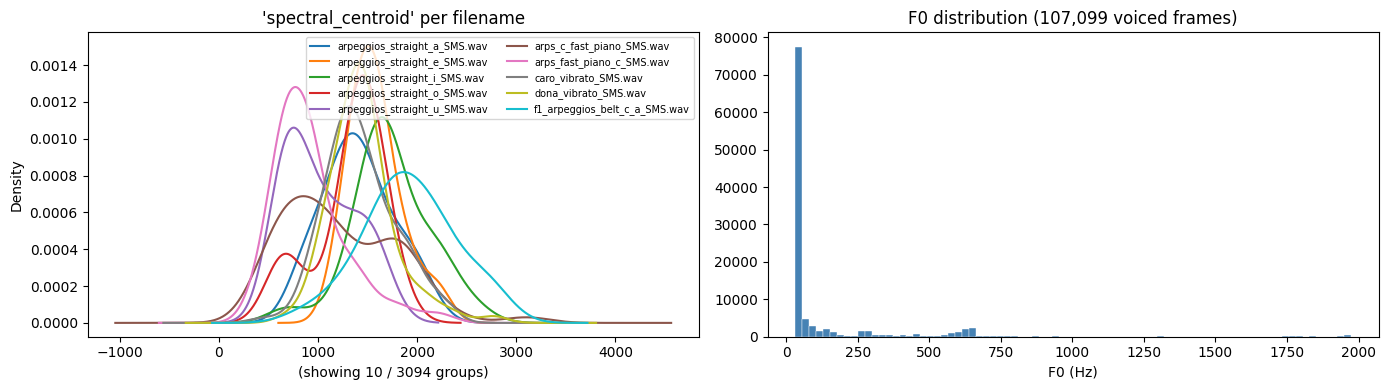

In [8]:
import matplotlib.pyplot as plt

# Summary stats
print("Feature summary (all frames):")
display(df[feat_columns].describe().T.round(4))

# Frames per file (top 20)
print(f"\nFrames per file (showing first 20 / {df['filename'].nunique()}):")
display(df.groupby("filename").size().rename("n_frames").to_frame().head(20))

# Distribution plot for first non-F0 feature
plot_feat = next((c for c in feat_columns if not c.startswith("f0_")), feat_columns[0])

# Pick grouping column: first metadata col if available, else filename
group_col = METADATA_COLS[0] if meta_lookup and METADATA_COLS[0] in df.columns else "filename"
n_groups = df[group_col].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# KDE per group (cap at 10 groups for readability)
ax = axes[0]
for i, (name, grp) in enumerate(df.groupby(group_col)):
    if i >= 10:
        ax.set_xlabel(f"(showing 10 / {n_groups} groups)")
        break
    grp[plot_feat].plot.kde(ax=ax, label=str(name)[:30])
ax.set_title(f"'{plot_feat}' per {group_col}")
ax.legend(fontsize=7, ncol=2)

# F0 histogram (if extracted)
ax = axes[1]
if "f0_hz" in df.columns:
    f0_valid = df["f0_hz"].dropna()
    ax.hist(f0_valid, bins=80, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_xlabel("F0 (Hz)")
    ax.set_title(f"F0 distribution ({len(f0_valid):,} voiced frames)")
else:
    ax.text(0.5, 0.5, "F0 extraction disabled", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="grey")
    ax.set_title("F0")

plt.tight_layout()
plt.show()